In [1]:
from SDEC.datos.codigos.lectura_datos import *
#import regionalizacion as reg
import matplotlib.pyplot as plt
import SDEC.regionalizacion.deep_cluster as dc
from sklearn.cluster import KMeans, AgglomerativeClustering
#import rpy2.robjects as ro
import pickle 
import copy
dir_datos = "datos"

%matplotlib inline
%load_ext autoreload
%autoreload 2

Can't load requested DLL: C:\Program Files\GeoDa Software\ogr_FileGDB.dll
126: The specified module could not be found.

Can't load requested DLL: C:\Program Files\GeoDa Software\ogr_FileGDB.dll
126: The specified module could not be found.

Can't load requested DLL: C:\Program Files\GeoDa Software\ogr_MSSQLSpatial.dll
126: The specified module could not be found.

Can't load requested DLL: C:\Program Files\GeoDa Software\ogr_MSSQLSpatial.dll
126: The specified module could not be found.

Can't load requested DLL: C:\Program Files\GeoDa Software\ogr_OCI.dll
126: The specified module could not be found.

Can't load requested DLL: C:\Program Files\GeoDa Software\ogr_OCI.dll
126: The specified module could not be found.

Can't load requested DLL: C:\Program Files\GeoDa Software\ogr_PG.dll
126: The specified module could not be found.

Can't load requested DLL: C:\Program Files\GeoDa Software\ogr_PG.dll
126: The specified module could not be found.

Can't load requested DLL: C:\Program Fil

In [2]:
covid,geo, centroides, codiprov,covid_acum,personas = df_covid()

regiones = {'noroeste' : ('Jujuy','Salta','Tucumán','Santiago del Estero','Catamarca'),
            'noreste'  : ('Formosa', 'Chaco', 'Misiones','Corrientes','Santa Fe','Entre Ríos'),
            'cuyo' : ('La Rioja','San Juan','Mendoza','San Luis'),
            'pampeana' : ('Córdoba', 'La Pampa', 'Buenos Aires','Ciudad Autónoma de Buenos Aires' ),
            'patagonia' : ('Neuquén', 'Río Negro', 'Chubut', 'Santa Cruz', 'Tierra del Fuego')    
    }


lista_regiones = []
errores = []
for i in range(len(codiprov)):
    prov = codiprov.iloc[i].provincia
    j = 1
    pertenece = False
    for k in regiones.keys():
        l = regiones[k]
        if prov in l:
            lista_regiones.append(j)
            pertenece = True
        else:
        
            pass
        j += 1
    if pertenece == False:
        errores.append(codiprov.iloc[i]) 


cov =  covid.loc[pd.IndexSlice[:,'2021-01'],:].copy()
cov['reg'] = lista_regiones

regiones = cov.reg.copy()
regiones[cov.provincia == "Tucumán"] = 6
cov['reg'] = regiones

El mes desde el cuál todos los dptos tienen al menos 1 contagiado es: 2021-01


In [3]:
from sklearn.metrics import *
def metricas_intrinsecas(datos, grupos):
    sil = round(silhouette_score(datos,grupos),5)
    cal = round(calinski_harabasz_score(datos,grupos),5)
    dav = round(davies_bouldin_score(datos, grupos),5)
    rdo = pd.DataFrame([sil,cal,dav], index = ['Siluetas', 'Kalinski','Davies'])
    return rdo

def metricas_extrinsecas(y_verd, y_pred):
    ami = adjusted_mutual_info_score(y_verd, y_pred)
    mi = mutual_info_score(y_verd, y_pred)
    hom = homogeneity_score(y_verd, y_pred)
    ran = rand_score(y_verd, y_pred)
    rdo = pd.DataFrame([ami,mi,hom,ran], index = ['Adj Mutual Inf', 'Mutual Inf', 'Homog','Rand score'])
    return rdo


In [4]:
gdf = gpd.read_file("SDEC/datos/simulaciones/sim2.shp")

In [5]:
from libpysal.weights import Queen, Rook, KNN

In [78]:
W_knn6 = KNN.from_dataframe(gdf, k = 6 )
W_knn4 = KNN.from_dataframe(gdf, k = 4 )
W_knn8 = KNN.from_dataframe(gdf, k = 100 )

In [79]:
def calc_sdec(datos, W, aglo = True):
    X = datos
    X1 = datos[:,:100]
    X2 = datos[:,100:]
    sdec = dc.sdec(6)
    sdec.gen_modelo()
    sdec.train_autoencoder([X1,X2],X)
    sdec.ajustar_modelo([X1,X2], W.sparse, aglo = aglo)
    return sdec

In [80]:
datos = gdf.drop('geometry', axis = 1).values

In [81]:
sdec_6 = calc_sdec(datos,W_knn6)

delta_label  0.0 < tol  0.0001
Reached tolerance threshold. Stopping training.


<AxesSubplot:>

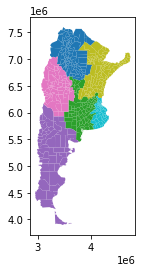

In [82]:
gdf.plot(sdec_6.y_pred, categorical = True)

In [83]:
sdec_6.model.summary()

Model: "model_29"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_19 (InputLayer)          [(None, 100)]        0           []                               
                                                                                                  
 input_20 (InputLayer)          [(None, 100)]        0           []                               
                                                                                                  
 dense_99 (Dense)               (None, 80)           8080        ['input_19[0][0]']               
                                                                                                  
 dense_102 (Dense)              (None, 80)           8080        ['input_20[0][0]']               
                                                                                           

In [84]:
sdec_6.autoencoder.summary()

Model: "model_27"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_19 (InputLayer)          [(None, 100)]        0           []                               
                                                                                                  
 input_20 (InputLayer)          [(None, 100)]        0           []                               
                                                                                                  
 dense_99 (Dense)               (None, 80)           8080        ['input_19[0][0]']               
                                                                                                  
 dense_102 (Dense)              (None, 80)           8080        ['input_20[0][0]']               
                                                                                           

In [85]:
sdec_4 = calc_sdec(datos,W_knn4, aglo = False)
sdec_8 = calc_sdec(datos,W_knn8)

delta_label  0.0 < tol  0.0001
Reached tolerance threshold. Stopping training.


<AxesSubplot:>

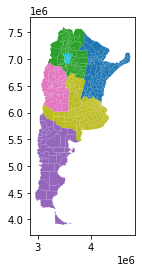

In [86]:
gdf.plot(sdec_4.y_pred, categorical = True)

<AxesSubplot:>

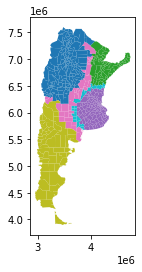

In [87]:
gdf.plot(sdec_8.y_pred, categorical = True)

In [88]:
w_all = np.ones((525,525))

In [89]:
from scipy.sparse import csr_matrix

w_all = csr_matrix(w_all)

In [90]:
X = datos
X1 = datos[:,:100]
X2 = datos[:,100:]
sdec = dc.sdec(6)
sdec.gen_modelo()
sdec.train_autoencoder([X1,X2],X)
sdec.ajustar_modelo([X1,X2], w_all, aglo = False)


<AxesSubplot:>

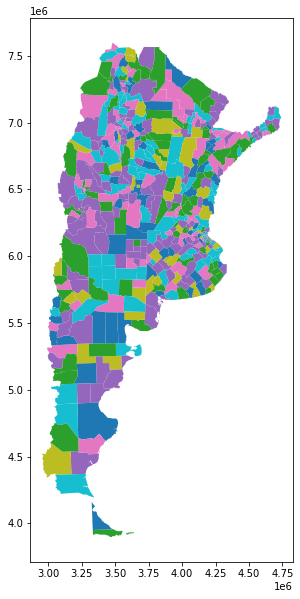

In [91]:
gdf.plot(sdec.y_pred, categorical = True, figsize = (12,10))

In [92]:
metricas_extrinsecas(regiones.values,sdec_6.y_pred)

,0
Adj Mutual Inf,0.769349
Mutual Inf,1.297119
Homog,0.817599
Rand score,0.885991


In [93]:
metricas_extrinsecas(regiones.values,sdec_4.y_pred)

,0
Adj Mutual Inf,0.971264
Mutual Inf,1.541388
Homog,0.971566
Rand score,0.991647


In [94]:
metricas_extrinsecas(regiones.values,sdec_8.y_pred)

,0
Adj Mutual Inf,0.581566
Mutual Inf,0.928151
Homog,0.585031
Rand score,0.810912


In [95]:
metricas_extrinsecas(regiones.values,sdec.y_pred)

,0
Adj Mutual Inf,0.011878
Mutual Inf,0.044208
Homog,0.027865
Rand score,0.667728


In [96]:
W_queen = Queen(gdf.geometry)

c:\Anaconda3\envs\covid2\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  warnings.warn(message)


In [97]:
sdec_queen = calc_sdec(datos,W_queen)

c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completi

delta_label  0.0 < tol  0.0001
Reached tolerance threshold. Stopping training.


c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


<AxesSubplot:>

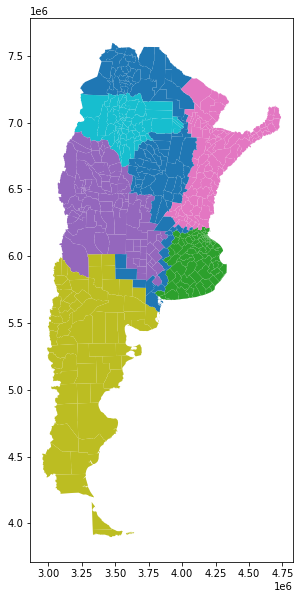

In [98]:
gdf.plot(sdec_queen.y_pred, categorical = True, figsize = (12,10))

In [99]:
metricas_extrinsecas(regiones.values,sdec_queen.y_pred)

,0
Adj Mutual Inf,0.642181
Mutual Inf,1.084732
Homog,0.683727
Rand score,0.836249


In [100]:
W_rook = Rook(gdf.geometry)

c:\Anaconda3\envs\covid2\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  warnings.warn(message)


In [101]:
sdec_rook = calc_sdec(datos,W_rook)

c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 3 > 1. Completi

In [102]:
metricas_extrinsecas(regiones.values,sdec_rook.y_pred)

,0
Adj Mutual Inf,0.700096
Mutual Inf,1.180471
Homog,0.744074
Rand score,0.854417


In [103]:
matriz = []
for i in regiones.values:
    v = []
    for j in regiones.values:
        if i == j:
            v.append(1)
        else:
            v.append(0)
    matriz.append(v)

In [104]:
w_real = np.array(matriz)-np.identity(525)
w_real = csr_matrix(w_real)

In [105]:
X = datos
X1 = datos[:,:100]
X2 = datos[:,100:]
sdec_real = dc.sdec(6)
sdec_real.gen_modelo()
sdec_real.train_autoencoder([X1,X2],X)
sdec_real.ajustar_modelo([X1,X2], w_real, aglo = False)


c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 6 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 6 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 6 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(
c:\Anaconda3\envs\covid2\lib\site-packages\sklearn\cluster\_agglomerative.py:280: UserWarning: the number of connected components of the connectivity matrix is 6 > 1. Completi

In [106]:
metricas_extrinsecas(regiones.values,sdec_real.y_pred)

,0
Adj Mutual Inf,0.841479
Mutual Inf,1.264658
Homog,0.797138
Rand score,0.860349


<AxesSubplot:>

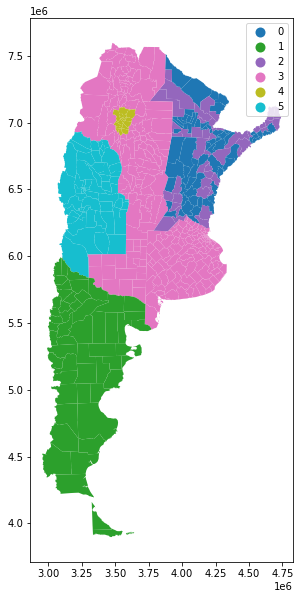

In [107]:
gdf.plot(sdec_real.y_pred, categorical = True, figsize = (12,10), legend = True)

In [108]:
w_real.todense()[0:,0].shape

(525, 1)

In [109]:
sdec.y_pred.shape

(525,)

In [110]:
rdos = metricas_extrinsecas(regiones.values,sdec_4.y_pred)
rdos = pd.concat([rdos,metricas_extrinsecas(regiones.values,sdec_6.y_pred)],axis = 1)
rdos = pd.concat([rdos,metricas_extrinsecas(regiones.values,sdec_8.y_pred)],axis = 1)
rdos = pd.concat([rdos,metricas_extrinsecas(regiones.values,sdec_queen.y_pred)],axis = 1)
rdos = pd.concat([rdos,metricas_extrinsecas(regiones.values,sdec_rook.y_pred)],axis = 1)
rdos = pd.concat([rdos,metricas_extrinsecas(regiones.values,sdec_real.y_pred)],axis = 1)
rdos.columns = ['knn4','knn6','knn8','queen','rook','w_real']
rdos

,knn4,knn6,knn8,queen,rook,w_real
Adj Mutual Inf,0.971264,0.769349,0.581566,0.642181,0.700096,0.841479
Mutual Inf,1.541388,1.297119,0.928151,1.084732,1.180471,1.264658
Homog,0.971566,0.817599,0.585031,0.683727,0.744074,0.797138
Rand score,0.991647,0.885991,0.810912,0.836249,0.854417,0.860349


In [111]:
#rdos.to_excel('Resultados/pruebas_matrices.xlsx')

In [112]:
W_knn4.mean_neighbors

4.0

In [113]:
W_rook.mean_neighbors

5.398095238095238

In [114]:
W_queen.mean_neighbors


5.443809523809524

In [115]:
import pysal.lib as ps

w_transf = ps.weights.WSP(w_real)
w_transf.to_W().mean_neighbors


c:\Anaconda3\envs\covid2\lib\site-packages\libpysal\weights\weights.py:172: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  warnings.warn(message)


123.32571428571428

In [116]:
vecinos = []

for k, i in W_rook.neighbors.items():
    vecinos.append(len(i))
np.median(vecinos)

5.0

In [117]:
vecinos = []

for k, i in W_queen.neighbors.items():
    vecinos.append(len(i))
np.median(vecinos)

5.0

In [118]:
vecinos = []

for k, i in w_transf.to_W().neighbors.items():
    vecinos.append(len(i))
np.median(vecinos)

111.0